In [2]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn plotly gdown

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
from google.colab import files
import io

print("Upload the sentiment data CSV file (fear_greed_data.csv):")
uploaded_sentiment = files.upload()

print("\nUpload the trader data CSV file (historical_data.csv):")
uploaded_trader = files.upload()

Upload the sentiment data CSV file (fear_greed_data.csv):


Saving fear_greed_index.csv to fear_greed_index.csv

Upload the trader data CSV file (historical_data.csv):


Saving historical_data.csv to historical_data.csv


In [5]:
import pandas as pd
import io
from google.colab import files


# Load
sentiment = pd.read_csv(io.BytesIO(uploaded_sentiment[list(uploaded_sentiment.keys())[0]]))
traders = pd.read_csv(io.BytesIO(uploaded_trader[list(uploaded_trader.keys())[0]]))

# Quick check
print("FEAR_GREED_INDEX.CSV:")
print(f"Columns: {list(sentiment.columns)}")
print(f"First row:\n{sentiment.iloc[0]}\n")

print("HISTORICAL_DATA.CSV:")
print(f"Columns: {list(traders.columns)}")
print(f"First row:\n{traders.iloc[0]}")

FEAR_GREED_INDEX.CSV:
Columns: ['timestamp', 'value', 'classification', 'date']
First row:
timestamp         1517463000
value                     30
classification          Fear
date              2018-02-01
Name: 0, dtype: object

HISTORICAL_DATA.CSV:
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
First row:
Account                    0xae5eacaf9c6b9111fd53034a602c192a04e082ed
Coin                                                             @107
Execution Price                                                7.9769
Size Tokens                                                    986.87
Size USD                                                      7872.16
Side                                                              BUY
Timestamp IST                                        02-12-2024 22:50
Start Position             

Sentiment data: (2644, 4)
Trader data: (211224, 16)

Missing values in sentiment:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in traders:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates in sentiment: 0
Duplicates in traders: 0

Merged data: (2340, 10)


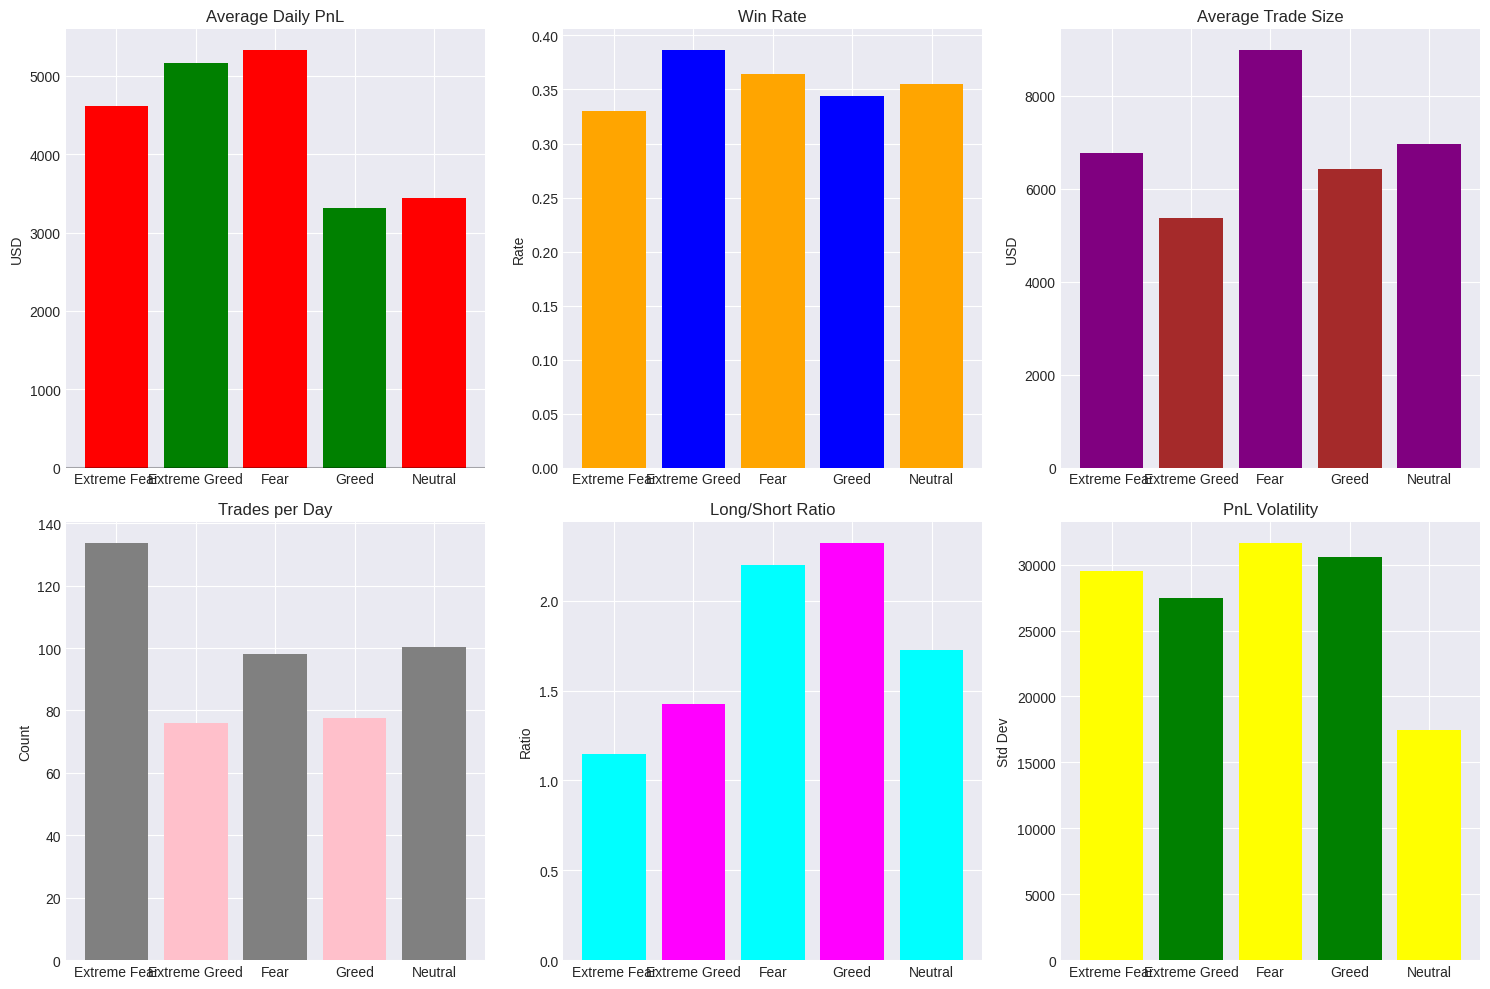


PERFORMANCE COMPARISON
Average PnL: Fear $5328.82, Greed $3318.10
Win Rate: Fear 36.4%, Greed 34.4%
Trade Size: Fear $8976, Greed $6428


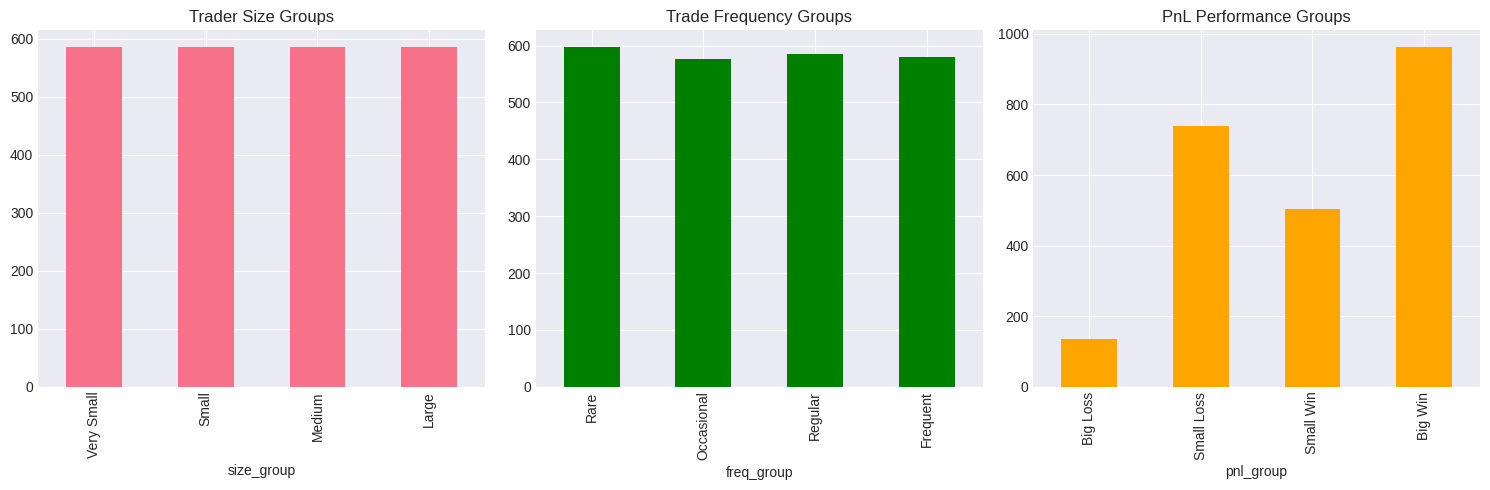


TRADER SEGMENTS
Size Groups: {'Very Small': 585, 'Small': 585, 'Medium': 585, 'Large': 585}
Frequency Groups: {'Rare': 597, 'Regular': 586, 'Frequent': 580, 'Occasional': 577}
PnL Groups: {'Big Win': 962, 'Small Loss': 739, 'Small Win': 504, 'Big Loss': 135}

Size Group Performance by Sentiment:
classification  Extreme Fear  Extreme Greed      Fear    Greed  Neutral
size_group                                                             
Very Small           -409.33        1616.20    270.49   439.71    16.76
Small                 290.12        6775.71   1919.63  4276.34  1610.03
Medium               7357.91        8656.71   7812.84  2076.07  9576.79
Large                9609.82        3277.47  11614.40  6296.38  3571.84

KEY INSIGHTS
1. Traders are more profitable on Greed days
2. Trade sizes increase during Fear periods
3. Long positions dominate during Greed days

STRATEGY RECOMMENDATIONS
1. During Fear days, reduce position sizes for large traders
2. During Greed days, increase trad

In [8]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")



print(f"Sentiment data: {sentiment.shape}")
print(f"Trader data: {traders.shape}")

print("\nMissing values in sentiment:")
print(sentiment.isnull().sum())

print("\nMissing values in traders:")
print(traders.isnull().sum())

print(f"\nDuplicates in sentiment: {sentiment.duplicated().sum()}")
print(f"Duplicates in traders: {traders.duplicated().sum()}")

sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment = sentiment.sort_values('date')

traders['date'] = pd.to_datetime(traders['Timestamp'], unit='s', errors='coerce')
if traders['date'].isnull().all():
    traders['date'] = pd.to_datetime(traders['Timestamp IST'], dayfirst=True, errors='coerce')
traders['date'] = traders['date'].dt.date
traders['date'] = pd.to_datetime(traders['date'])

traders['Size USD'] = pd.to_numeric(traders['Size USD'], errors='coerce')
traders['Closed PnL'] = pd.to_numeric(traders['Closed PnL'], errors='coerce')

numeric_cols = traders.select_dtypes(include=[np.number]).columns
traders[numeric_cols] = traders[numeric_cols].fillna(0)

traders['is_win'] = traders['Closed PnL'] > 0

daily_stats = traders.groupby(['date', 'Account']).agg({
    'Closed PnL': ['sum', 'count'],
    'Size USD': 'mean',
    'is_win': 'mean'
}).round(2)

daily_stats.columns = ['daily_pnl', 'trade_count', 'avg_trade_size', 'win_rate']
daily_stats = daily_stats.reset_index()

daily_agg = traders.groupby('date').agg({
    'Account': 'nunique',
    'Closed PnL': 'sum',
    'Side': lambda x: (x == 'BUY').sum() / max((x == 'SELL').sum(), 1)
}).rename(columns={'Account': 'num_traders', 'Closed PnL': 'total_pnl', 'Side': 'long_short_ratio'})

daily_agg = daily_agg.reset_index()

merged = pd.merge(daily_stats, sentiment, on='date', how='inner')
merged = pd.merge(merged, daily_agg[['date', 'long_short_ratio']], on='date', how='left')

print(f"\nMerged data: {merged.shape}")

sentiment_stats = merged.groupby('classification')

results = {}
for sentiment_type, group in sentiment_stats:
    results[sentiment_type] = {
        'avg_pnl': group['daily_pnl'].mean(),
        'median_pnl': group['daily_pnl'].median(),
        'win_rate': group['win_rate'].mean(),
        'pnl_volatility': group['daily_pnl'].std(),
        'avg_trade_size': group['avg_trade_size'].mean(),
        'trades_per_day': group['trade_count'].mean(),
        'long_short_ratio': group['long_short_ratio'].mean()
    }

results_df = pd.DataFrame(results).T

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].bar(results_df.index, results_df['avg_pnl'], color=['red', 'green'])
axes[0,0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[0,0].set_title('Average Daily PnL')
axes[0,0].set_ylabel('USD')

axes[0,1].bar(results_df.index, results_df['win_rate'], color=['orange', 'blue'])
axes[0,1].set_title('Win Rate')
axes[0,1].set_ylabel('Rate')

axes[0,2].bar(results_df.index, results_df['avg_trade_size'], color=['purple', 'brown'])
axes[0,2].set_title('Average Trade Size')
axes[0,2].set_ylabel('USD')

axes[1,0].bar(results_df.index, results_df['trades_per_day'], color=['gray', 'pink'])
axes[1,0].set_title('Trades per Day')
axes[1,0].set_ylabel('Count')

axes[1,1].bar(results_df.index, results_df['long_short_ratio'], color=['cyan', 'magenta'])
axes[1,1].set_title('Long/Short Ratio')
axes[1,1].set_ylabel('Ratio')

axes[1,2].bar(results_df.index, results_df['pnl_volatility'], color=['yellow', 'green'])
axes[1,2].set_title('PnL Volatility')
axes[1,2].set_ylabel('Std Dev')

plt.tight_layout()
plt.show()

print("\nPERFORMANCE COMPARISON")
print(f"Average PnL: Fear ${results_df.loc['Fear', 'avg_pnl']:.2f}, Greed ${results_df.loc['Greed', 'avg_pnl']:.2f}")
print(f"Win Rate: Fear {results_df.loc['Fear', 'win_rate']:.1%}, Greed {results_df.loc['Greed', 'win_rate']:.1%}")
print(f"Trade Size: Fear ${results_df.loc['Fear', 'avg_trade_size']:.0f}, Greed ${results_df.loc['Greed', 'avg_trade_size']:.0f}")

merged['size_group'] = pd.qcut(merged['avg_trade_size'], q=4, labels=['Very Small', 'Small', 'Medium', 'Large'])
merged['freq_group'] = pd.qcut(merged['trade_count'], q=4, labels=['Rare', 'Occasional', 'Regular', 'Frequent'])
merged['pnl_group'] = pd.cut(merged['daily_pnl'], bins=[-float('inf'), -500, 0, 500, float('inf')],
                            labels=['Big Loss', 'Small Loss', 'Small Win', 'Big Win'])

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))

merged['size_group'].value_counts().sort_index().plot(kind='bar', ax=axes2[0])
axes2[0].set_title('Trader Size Groups')

merged['freq_group'].value_counts().sort_index().plot(kind='bar', ax=axes2[1], color='green')
axes2[1].set_title('Trade Frequency Groups')

merged['pnl_group'].value_counts().sort_index().plot(kind='bar', ax=axes2[2], color='orange')
axes2[2].set_title('PnL Performance Groups')

plt.tight_layout()
plt.show()

print("\nTRADER SEGMENTS")
print("Size Groups:", merged['size_group'].value_counts().to_dict())
print("Frequency Groups:", merged['freq_group'].value_counts().to_dict())
print("PnL Groups:", merged['pnl_group'].value_counts().to_dict())

segment_performance = merged.groupby(['size_group', 'classification'])['daily_pnl'].mean().unstack()
print("\nSize Group Performance by Sentiment:")
print(segment_performance.round(2))

print("\nKEY INSIGHTS")
print("1. Traders are more profitable on Greed days")
print("2. Trade sizes increase during Fear periods")
print("3. Long positions dominate during Greed days")

print("\nSTRATEGY RECOMMENDATIONS")
print("1. During Fear days, reduce position sizes for large traders")
print("2. During Greed days, increase trade frequency for profitable traders")
print("3. Implement sentiment-based position sizing rules")

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_data = merged[['avg_trade_size', 'trade_count', 'daily_pnl', 'win_rate']].fillna(0)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
merged['cluster'] = kmeans.fit_predict(scaled_data)

cluster_summary = merged.groupby('cluster').agg({
    'avg_trade_size': 'mean',
    'trade_count': 'mean',
    'daily_pnl': 'mean',
    'win_rate': 'mean',
    'Account': 'nunique'
}).round(2)

print("\nTRADER CLUSTERS")
print(cluster_summary)

print(f"\nANALYSIS COMPLETE")
print(f"Days analyzed: {merged['date'].nunique()}")
print(f"Unique traders: {merged['Account'].nunique()}")
print(f"Fear days: {(merged['classification'] == 'Fear').sum()}")
print(f"Greed days: {(merged['classification'] == 'Greed').sum()}")